# Identifying M4 cluster members w/ Dense Neural Networks

_NOTE_: I don't include the data here to keep things small.  Please get the data from the [class repo](https://github.com/uo-phys/sci-comp-spring23).

Demonstrate the use of a densely connected neural network, like the one we trained on the MNIST data set, for classifying stars in the M4 cluster using Gaia's measurements of stars' locations on the sky (right ascension and declination).  This is basically a repeat of what we covered in class, but this time I want you to even out the training set to include roughly equal numbers of M4 members and non-members.

1. What training and validation accuracies are you able to achieve?

2. Is your trained model confident that any of the stars in your test set are part of M4?

3. What did your model learn?  Can you come up with a useful way to probe your model and visualize the results to answer this question?

4. Do you think more sophisticated models could do better with this classification task using only sky positions?  Use the properties of the training set to make your argument.

**510 students:**

Make use of other features observed by Gaia to improve your classifier.  Be sure to use the data model documentation to understand what each feature is, and explain why you think it would be useful for identifying cluster members.  What training and validation accuracies can you achieve?  Does your trained model find any stars it believes are confidently in M4 that weren't in the M4 catalog?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import jax
from jax import random
import jax.numpy as jnp
import numpyro.distributions as dist
import numpyro
import arviz as az
from numpyro import infer

import tensorflow as tf
import tensorflow_datasets as tfds

from flax import linen as nn

In [2]:
M4=pd.read_fwf('../data/NGC6121-1.dat', names=['source_id', 'ra', 'dec','phot_g_mean_mag'])
M4

,source_id,ra,dec,phot_g_mean_mag
0,6045504229661220736,245.99162,-26.34434,18.438
1,6045504981264184192,246.03035,-26.28057,18.769
2,6045508902585952640,245.88761,-26.24297,19.072
3,6045507180287440000,245.85343,-26.28453,18.495
4,6045503473747038464,245.87124,-26.34628,17.163
...,...,...,...,...
19503,6045337962873610240,245.13976,-27.09970,19.705
19504,6045298891556291712,245.48339,-27.19208,19.493
19505,6045305866578950784,245.69445,-27.06942,18.290
19506,6045303774938119808,245.80824,-27.07275,19.267


In [3]:
Data=pd.read_csv('../../hub_data_share/m4_gaia_source.csv')
Data.head

<bound method NDFrame.head of                          designation            source_id          ra  \
0       Gaia DR3 6048466004733106048  6048466004733106048  244.500044   
1       Gaia DR3 6048666665606296064  6048666665606296064  244.500060   
2       Gaia DR3 6048358561832132864  6048358561832132864  244.500066   
3       Gaia DR3 6048842759265408128  6048842759265408128  244.500077   
4       Gaia DR3 6048837635368203648  6048837635368203648  244.500085   
...                              ...                  ...         ...   
494991  Gaia DR3 6045943823843054720  6045943823843054720  247.499972   
494992  Gaia DR3 6045551057673424000  6045551057673424000  247.499973   
494993  Gaia DR3 6045942277654774400  6045942277654774400  247.499973   
494994  Gaia DR3 6045526662257584000  6045526662257584000  247.499979   
494995  Gaia DR3 6045975164219350656  6045975164219350656  247.499981   

              dec  parallax  parallax_error  parallax_over_error         pm  \
0      -26.152

In [4]:
Data.columns

Index(['designation', 'source_id', 'ra', 'dec', 'parallax', 'parallax_error',
       'parallax_over_error', 'pm', 'pmra', 'pmra_error', 'pmdec',
       'pmdec_error', 'astrometric_n_good_obs_al', 'astrometric_chi2_al',
       'visibility_periods_used', 'phot_g_mean_flux_over_error',
       'phot_g_mean_mag', 'phot_bp_mean_flux_over_error', 'phot_bp_mean_mag',
       'phot_rp_mean_flux_over_error', 'phot_rp_mean_mag',
       'phot_bp_rp_excess_factor', 'bp_rp', 'radial_velocity',
       'radial_velocity_error'],
      dtype='object')

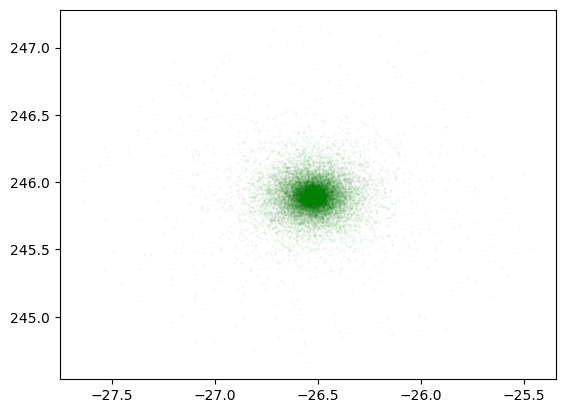

In [5]:
plt.scatter(M4['dec'],M4['ra'], alpha=.1, s=.1, color='g');

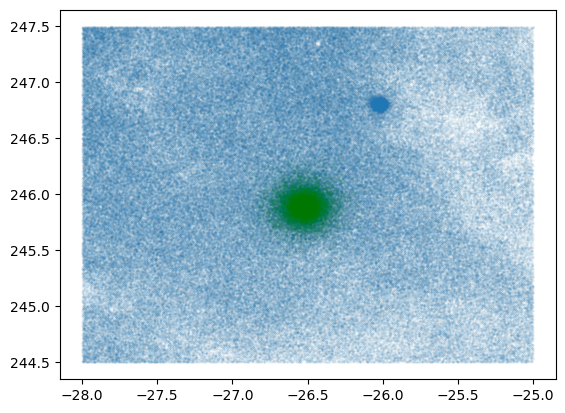

In [7]:
plt.scatter(Data['dec'],Data['ra'], alpha=.1,s=.1)
plt.scatter(M4['dec'],M4['ra'], alpha=.1, s=.1, color='g');

In [8]:
n_classes = 2

# This is useful for making plots it takes an integer
lookup_dict={
    0:'In Cluster',
    1 :'Not in Cluster',
}

labels = list(lookup_dict.values())

Data subsets needed:
train inputs ('dec' and 'ra')
train outputs (true/false or 1/0)
test inputs 
test outputs
